![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







# Import in apple verion
### Check Critical Package Version
✅ JAX: 0.6.2
✅ MuJoCo: 3.3.6
✅ Brax: 0.13.0
✅ Flax: 0.10.7

In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from learning.notebooks.apple_mujoco_setup import *
import jax
import jax.numpy as jnp
import numpy as np
import mediapy
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.acme import running_statistics
from flax import serialization
from mujoco_playground import registry
import wandb
import os
import matplotlib.pyplot as plt




In [4]:
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
run_id = "random_qpos_lr0.0005_512_20260202_074028_8626"  # Replace with your run

# --- Create output folder ---
os.makedirs("evaluation/downloaded_policies", exist_ok=True)

# --- Download artifact ---
api = wandb.Api()
run = api.run(f"{user}/{project}/{run_id}")

# Find the policy artifact
artifacts = run.logged_artifacts()
policy_artifact = None
for artifact in artifacts:
    if artifact.type == "model":
        policy_artifact = artifact
        break

if policy_artifact is None:
    raise ValueError(f"No model artifact found for run {run_id}")

print(f"Found artifact: {policy_artifact.name}")

# Download to local folder
artifact_dir = policy_artifact.download(root="downloaded_policies")
print(f"Downloaded to: {artifact_dir}")

# Load the parameters
params_path = os.path.join(artifact_dir, "params.msgpack")
with open(params_path, "rb") as f:
    params_bytes = f.read()

print(f"✓ Loaded params ({len(params_bytes) / 1024:.1f} KB)")

Found artifact: policy_parameters_random_qpos_lr0.0005_512_20260202_074028_8626:v0


wandb:   2 of 2 files downloaded.  


Downloaded to: downloaded_policies
✓ Loaded params (1116.7 KB)


In [5]:
# Check top-level structure
import msgpack

with open(params_path, "rb") as f:
    raw = msgpack.unpackb(f.read(), raw=False, strict_map_key=False)

print(f"Top-level type: {type(raw)}")
print(f"Number of elements: {len(raw)}")
print(f"Keys/indices: {list(raw.keys()) if isinstance(raw, dict) else range(len(raw))}")

# Show structure of each top-level element
for i, item in enumerate(raw) if isinstance(raw, (list, tuple)) else raw.items():
    if isinstance(raw, dict):
        i, item = i, raw[i]
    print(f"\n=== Element {i} ===")
    if isinstance(item, dict):
        print(f"  Keys: {list(item.keys())}")
    else:
        print(f"  Type: {type(item)}")

Top-level type: <class 'dict'>
Number of elements: 3
Keys/indices: ['0', '1', '2']

=== Element 0 ===
  Keys: ['mean', 'std', 'count', 'summed_variance']

=== Element 1 ===
  Keys: ['params']

=== Element 2 ===
  Keys: ['params']


In [6]:
import jax
import jax.numpy as jnp
import numpy as np
import mediapy
import os
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.acme import running_statistics
from flax import serialization
from mujoco_playground import registry

# --- Create output folder ---
os.makedirs("evaluation/graphs", exist_ok=True)

# --- Config ---
env_name = "UR10PickCube"
episode_length = 150
seed = 42
video_path = "evaluation/graphs/"
video_tag = "rollout_video.mp4"
camera_kwargs = {"camera": "side_130", "width": 800, "height": 600}

# --- Load environment ---
env = registry.load(env_name)
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

# --- Rebuild network ---
obs_size = env.observation_size
action_size = env.action_size
print(f"Obs size: {obs_size}, Action size: {action_size}")

normalize = running_statistics.normalize
ppo_network = ppo_networks.make_ppo_networks(
    observation_size=obs_size,
    action_size=action_size,
    preprocess_observations_fn=normalize,
)

# --- Build template matching saved structure ---
rng = jax.random.PRNGKey(0)

dummy_normalizer_params = running_statistics.init_state(
    jax.ShapeDtypeStruct((obs_size,), jnp.float32)
)
dummy_policy_params = ppo_network.policy_network.init(rng)
dummy_value_params = ppo_network.value_network.init(rng)

params_template = {
    "0": dummy_normalizer_params,
    "1": dummy_policy_params,
    "2": dummy_value_params,
}

# --- Deserialize ---
params = serialization.from_bytes(params_template, params_bytes)
normalizer_params = params["0"]
policy_params = params["1"]
value_params = params["2"]
print("✓ Params restored")

# --- Run rollout ---
rng = jax.random.PRNGKey(seed)
rng, reset_rng = jax.random.split(rng)
state = jit_reset(reset_rng)

rollout = [state]
total_reward = 0.0
step_rewards = []  # Collect per-step rewards

for step in range(episode_length):
    rng, act_rng = jax.random.split(rng)
    
    # DON'T pre-normalize! apply() handles normalization internally
    raw_output = ppo_network.policy_network.apply(normalizer_params, policy_params, state.obs)
    
    # Network outputs [mean, log_std] concatenated -> take first half (mean)
    action = raw_output[:action_size]
    
    state = jit_step(state, action)
    rollout.append(state)
    
    reward = float(state.reward)
    step_rewards.append(reward)
    total_reward += reward

# Calculate statistics
step_rewards = np.array(step_rewards)
mean_step_reward = step_rewards.mean()

print(f"✓ Rollout complete")
print(f"  Total reward:      {total_reward:.2f}")
print(f"  Mean step reward:  {mean_step_reward:.4f}")
print(f"  Min step reward:   {step_rewards.min():.4f}")
print(f"  Max step reward:   {step_rewards.max():.4f}")

# --- Render video ---
frames = env.render(rollout, **camera_kwargs)
frames = np.asarray(frames).astype(np.uint8)

fps = int(1.0 / env.dt)
full_video_path = os.path.join(video_path, video_tag)
# mediapy.write_video(full_video_path, frames, fps=fps)
# print(f"✓ Video saved to {full_video_path}")

# Display in notebook
mediapy.show_video(frames, fps=fps)

✓ Using keyframe: 'low_home'
  Initial qpos size: 15
  Robot joints: [ 0.   -1.7   2.25 -2.15 -1.5  -1.5   0.    0.  ]
Available sensors:
  - left_finger_pad_floor_found
  - right_finger_pad_floor_found
  - hand_capsule_floor_found
  - box_hand_found
  - left_finger_box_contact
  - right_finger_box_contact
  - tcp_position
  - box_position
Obs size: 63, Action size: 7
✓ Params restored


/Users/matthiasweiss/miniconda3/envs/mujoco/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


✓ Rollout complete
  Total reward:      103.24
  Mean step reward:  0.6882
  Min step reward:   0.0076
  Max step reward:   4.0011


100%|██████████| 151/151 [00:01<00:00, 101.39it/s]


This browser does not support the video tag.


## Get mean reward of some number of rollouts

Running 50 rollouts...
  Completed 10/50 rollouts
  Completed 20/50 rollouts
  Completed 30/50 rollouts
  Completed 40/50 rollouts
  Completed 50/50 rollouts

✓ All rollouts complete
  Mean reward:   266.80
  Std reward:    233.96
  Min reward:    92.22
  Max reward:    1380.24


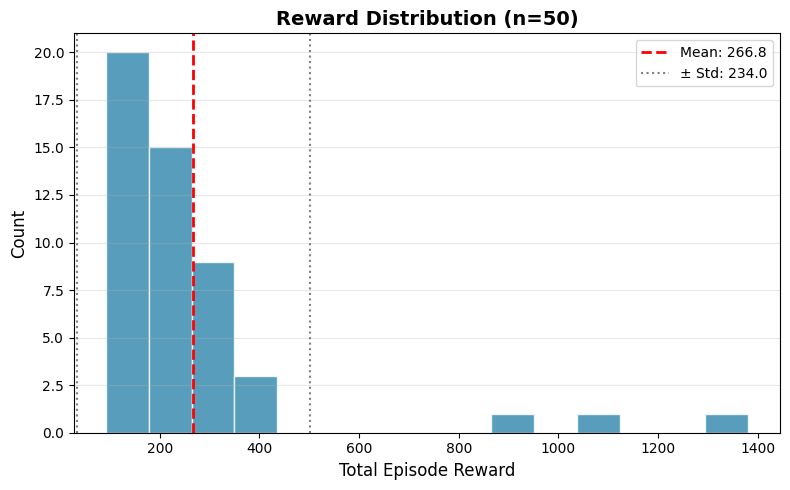

In [7]:
# --- Multiple Rollouts for Statistics ---
num_rollouts = 50
episode_length = 150
seed_base = 100  # Different from video rollout seed

# Collect total rewards
total_rewards = []

print(f"Running {num_rollouts} rollouts...")

for i in range(num_rollouts):
    rng = jax.random.PRNGKey(seed_base + i)
    rng, reset_rng = jax.random.split(rng)
    state = jit_reset(reset_rng)
    
    episode_reward = 0.0
    
    for step in range(episode_length):
        rng, act_rng = jax.random.split(rng)
        
        # Apply policy (no pre-normalization - apply() handles it)
        raw_output = ppo_network.policy_network.apply(normalizer_params, policy_params, state.obs)
        action = raw_output[:action_size]
        
        state = jit_step(state, action)
        episode_reward += float(state.reward)
    
    total_rewards.append(episode_reward)
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i + 1}/{num_rollouts} rollouts")

total_rewards = np.array(total_rewards)

print(f"\n✓ All rollouts complete")
print(f"  Mean reward:   {total_rewards.mean():.2f}")
print(f"  Std reward:    {total_rewards.std():.2f}")
print(f"  Min reward:    {total_rewards.min():.2f}")
print(f"  Max reward:    {total_rewards.max():.2f}")

# --- Histogram ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(total_rewards, bins=15, color="#2E86AB", edgecolor="white", alpha=0.8)

# Mean line
ax.axvline(
    total_rewards.mean(), 
    color="red", 
    linestyle="--", 
    linewidth=2, 
    label=f"Mean: {total_rewards.mean():.1f}"
)

# Std lines
ax.axvline(
    total_rewards.mean() - total_rewards.std(), 
    color="gray", 
    linestyle=":", 
    linewidth=1.5
)
ax.axvline(
    total_rewards.mean() + total_rewards.std(), 
    color="gray", 
    linestyle=":", 
    linewidth=1.5,
    label=f"± Std: {total_rewards.std():.1f}"
)

ax.set_xlabel("Total Episode Reward", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Reward Distribution (n={num_rollouts})", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
# plt.savefig("evaluation/graphs/reward_histogram.pdf", bbox_inches="tight", dpi=300)
# plt.savefig("evaluation/graphs/reward_histogram.png", bbox_inches="tight", dpi=300)
plt.show()

# print(f"\n✓ Saved to evaluation/graphs/reward_histogram.pdf")